# Lab 09 - Random Forest Classification
## Heart Disease Prediction using Random Forest Classifier

**Objective:** To implement a Random Forest Classifier for predicting heart disease and compare its performance with individual decision trees.

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

### 2. Load the Dataset

In [2]:
# Define column names for the Cleveland Heart Disease dataset
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Load the dataset
df = pd.read_csv('processed.cleveland.data', header=None, names=columns, na_values='?')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### 3. Exploratory Data Analysis

In [3]:
# Dataset info
print("Dataset Info:")
print(df.info())
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Handle missing values
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')
df.fillna(df.median(), inplace=True)

# Convert target to binary
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("\nTarget distribution:")
print(df['target'].value_counts())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


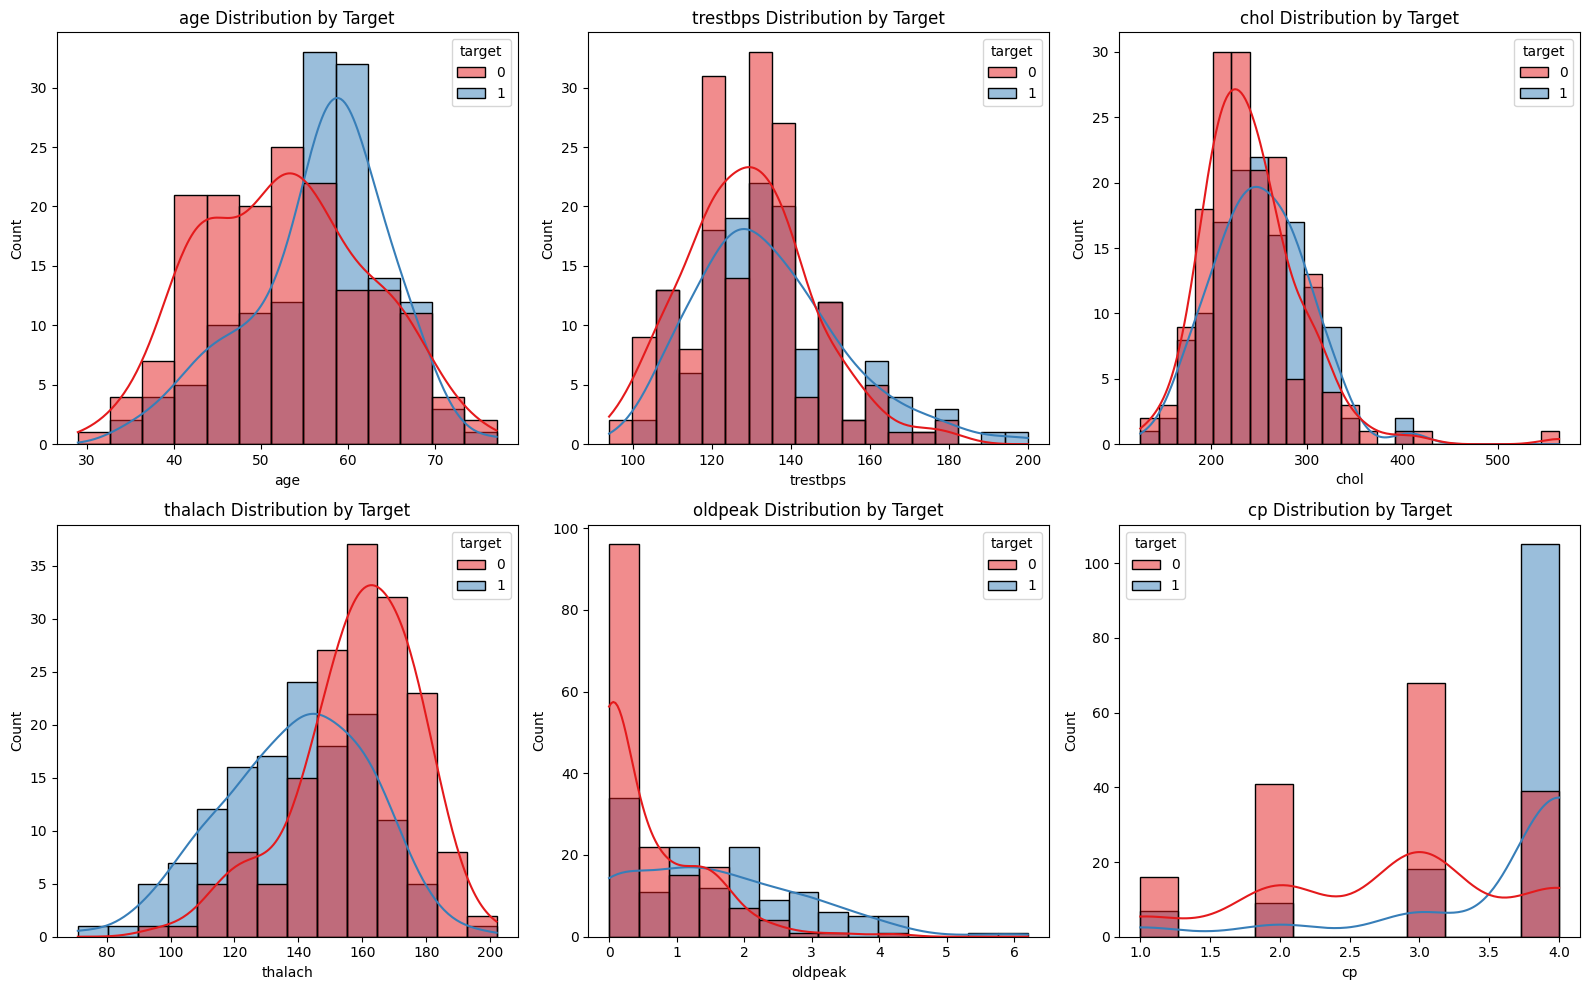

In [5]:
# Distribution of features by target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'cp']

for i, feature in enumerate(features_to_plot):
    row, col = i // 3, i % 3
    sns.histplot(data=df, x=feature, hue='target', kde=True, ax=axes[row][col], palette='Set1')
    axes[row][col].set_title(f'{feature} Distribution by Target')

plt.tight_layout()
plt.show()

### 4. Data Preprocessing

In [6]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 242
Testing set size: 61


### 5. Build Random Forest Model

In [7]:
# Create and train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_classifier.predict(X_test)

print("Random Forest Classifier trained successfully!")
print(f"Number of trees: {rf_classifier.n_estimators}")

Random Forest Classifier trained successfully!
Number of trees: 100


### 6. Model Evaluation

In [8]:
# Accuracy and Classification Report
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

Random Forest Accuracy: 0.8689

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.90      0.87        29
     Disease       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



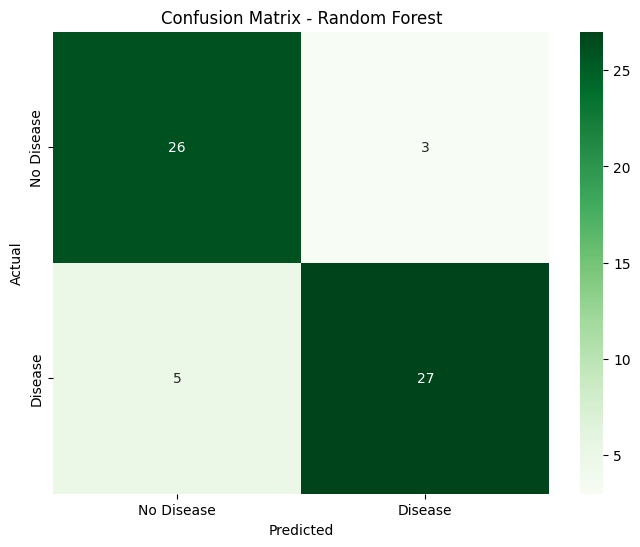

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 7. Feature Importance

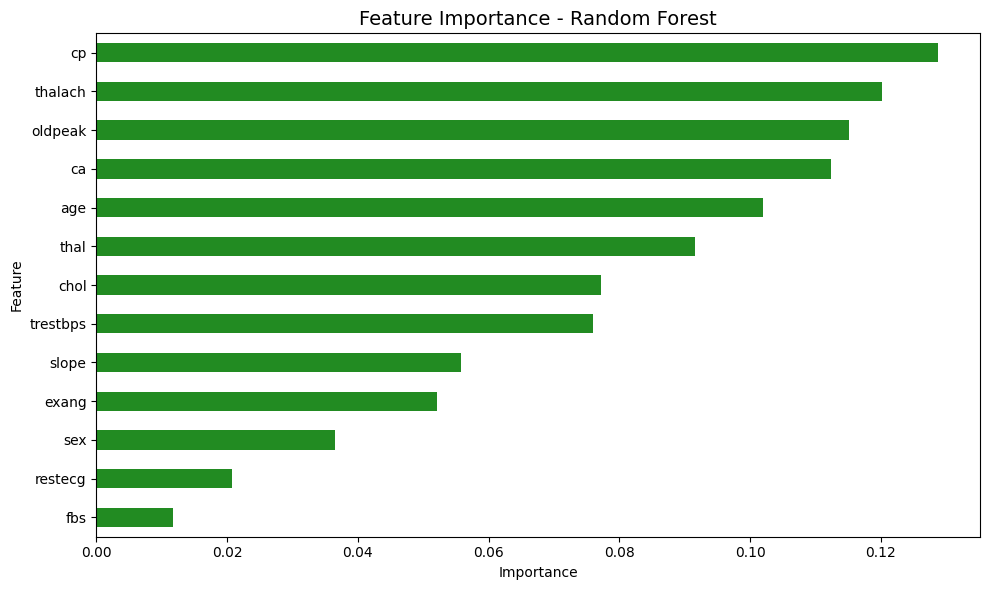


Top 5 important features:
cp         0.128705
thalach    0.120106
oldpeak    0.115099
ca         0.112426
age        0.101976
dtype: float64


In [10]:
# Feature Importance
feature_importance = pd.Series(rf_classifier.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='forestgreen')
plt.title('Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 important features:")
print(feature_importance.sort_values(ascending=False).head())

### 8. Comparison: Random Forest vs Decision Tree

In [11]:
# Train a single Decision Tree for comparison
dt_classifier = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"\nImprovement: {(accuracy_rf - accuracy_dt)*100:.2f}%")

# Cross-validation comparison
cv_dt = cross_val_score(dt_classifier, X, y, cv=5)
cv_rf = cross_val_score(rf_classifier, X, y, cv=5)

print(f"\nCross-Validation Results (5-fold):")
print(f"Decision Tree: {cv_dt.mean():.4f} (+/- {cv_dt.std():.4f})")
print(f"Random Forest: {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")

Decision Tree Accuracy: 0.7541
Random Forest Accuracy: 0.8689

Improvement: 11.48%

Cross-Validation Results (5-fold):
Decision Tree: 0.7456 (+/- 0.0983)
Random Forest: 0.8281 (+/- 0.0484)


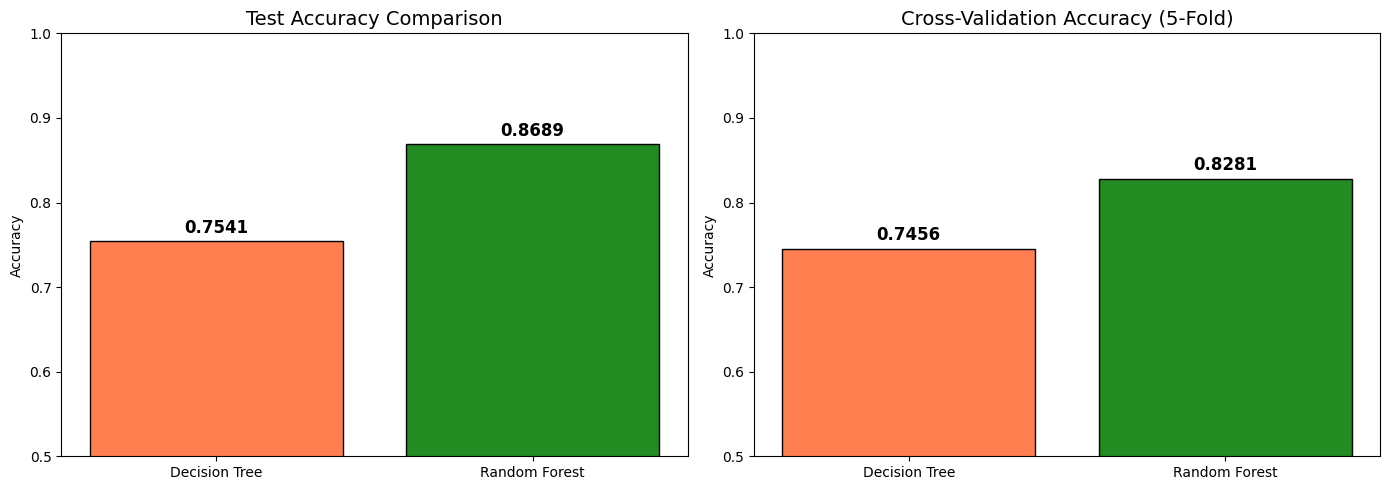

In [12]:
# Visual comparison
models = ['Decision Tree', 'Random Forest']
accuracies = [accuracy_dt, accuracy_rf]
cv_means = [cv_dt.mean(), cv_rf.mean()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test Accuracy
bars1 = axes[0].bar(models, accuracies, color=['coral', 'forestgreen'], edgecolor='black')
axes[0].set_title('Test Accuracy Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold')

# Cross-Validation
bars2 = axes[1].bar(models, cv_means, color=['coral', 'forestgreen'], edgecolor='black')
axes[1].set_title('Cross-Validation Accuracy (5-Fold)', fontsize=14)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
for bar, acc in zip(bars2, cv_means):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 9. ROC Curve

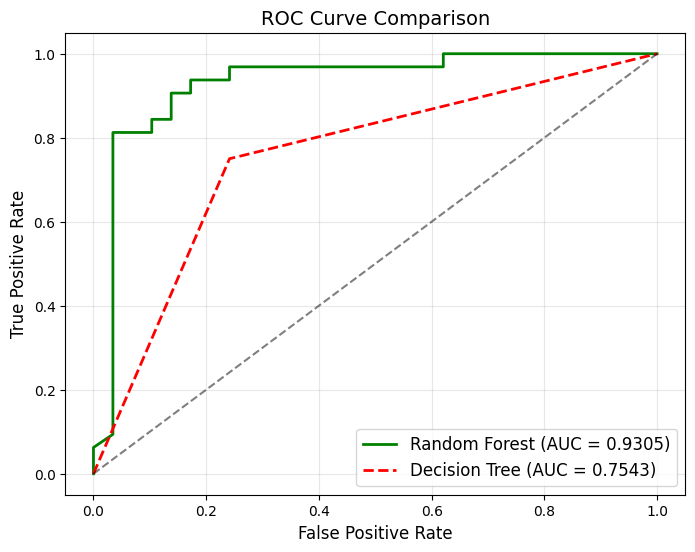

In [13]:
# ROC Curve
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]
y_prob_dt = dt_classifier.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

auc_rf = auc(fpr_rf, tpr_rf)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_dt, tpr_dt, 'r--', linewidth=2, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### 10. Effect of Number of Trees

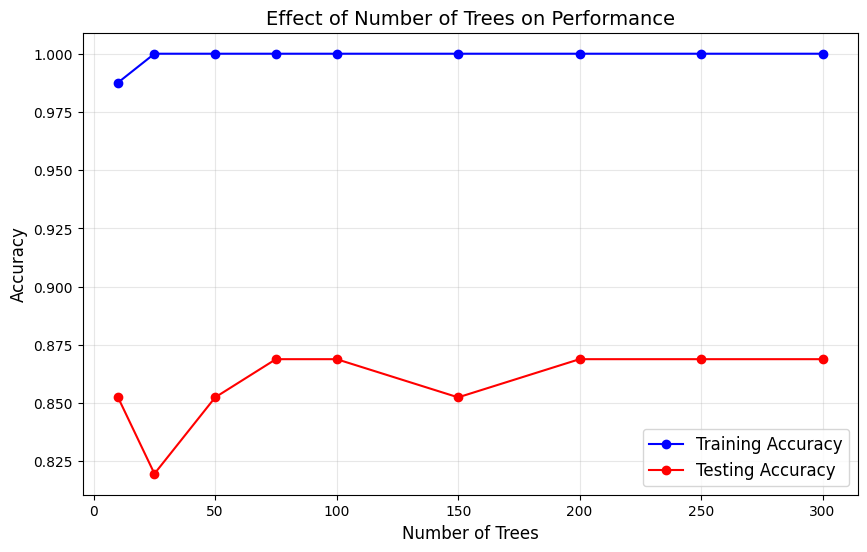

In [14]:
# Effect of n_estimators
n_trees = [10, 25, 50, 75, 100, 150, 200, 250, 300]
train_acc = []
test_acc = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    train_acc.append(rf.score(X_train, y_train))
    test_acc.append(rf.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(n_trees, train_acc, 'b-o', label='Training Accuracy')
plt.plot(n_trees, test_acc, 'r-o', label='Testing Accuracy')
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Effect of Number of Trees on Performance', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### 11. Conclusion

In this lab, we implemented a Random Forest Classifier on the Cleveland Heart Disease dataset and compared it with a single Decision Tree. The Random Forest demonstrated improved performance due to its ensemble approach. We analyzed feature importances, plotted ROC curves, and studied the effect of the number of trees on model performance. The ensemble method helps reduce overfitting and provides more robust predictions.